Task 1 - Importing all the library

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats
from scipy.stats import skew
%matplotlib inline

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12,8)

Task 2 - Load the Data

The advertisement dataset captures sales revenue genertated with respect to advertisement spent across multiple channels like TV, Radio and newspaper

In [ ]:
df=pd.read_csv('Advertising.csv')
df.head(10)

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,10.6


Task 3 - relationship between features and response

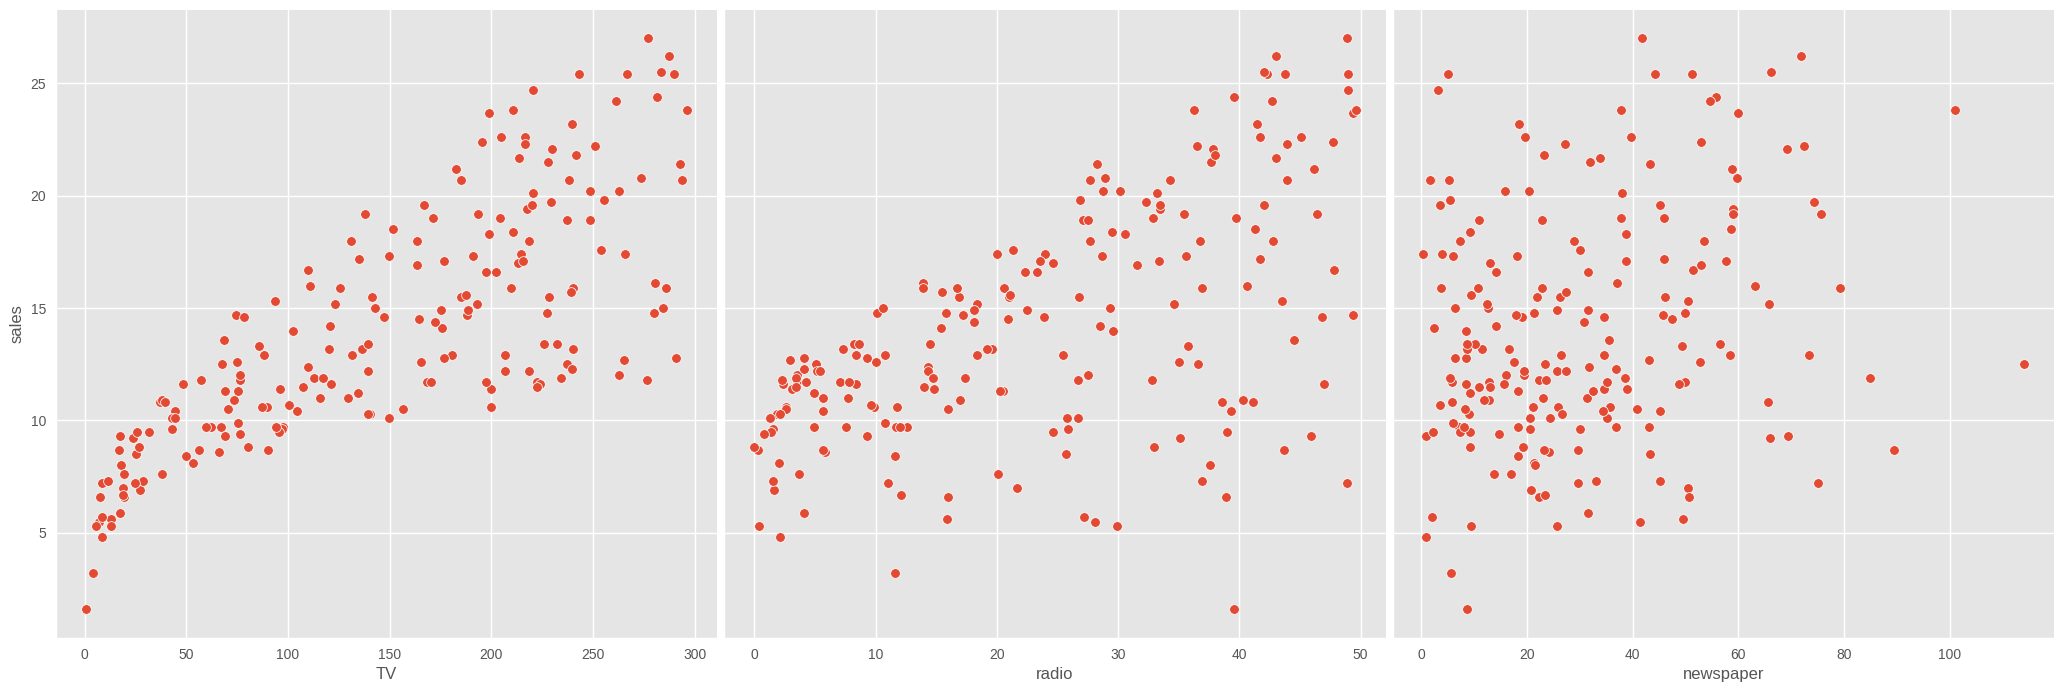

In [ ]:
sns.pairplot(df,x_vars=['TV','radio','newspaper'], y_vars='sales', height=7, aspect=1)

Task 4 - Multiple Linear Regression Model - Estimating Coefficients

In [ ]:
from sklearn.linear_model import LinearRegression
x = df.drop('sales', axis=1)
y = df['sales']

lm1 = LinearRegression()
lm1.fit(x,y)

print(lm1.intercept_)
print(lm1.coef_)

2.938889369459412
[ 0.04576465  0.18853002 -0.00103749]


In [ ]:
# store feature names
feature_name = ['Tv','radio','newspaper']
# get regression coefficiants
coefficiants = lm1.coef_
# creating  dictionary to map each column  to its coefficiants
feature_coefficient= dict(zip(feature_name,coefficiants))
# displaying the coefficient
feature_coefficient

{'Tv': np.float64(0.0457646454553976),
 'radio': np.float64(0.18853001691820448),
 'newspaper': np.float64(-0.0010374930424763285)}

<Axes: >

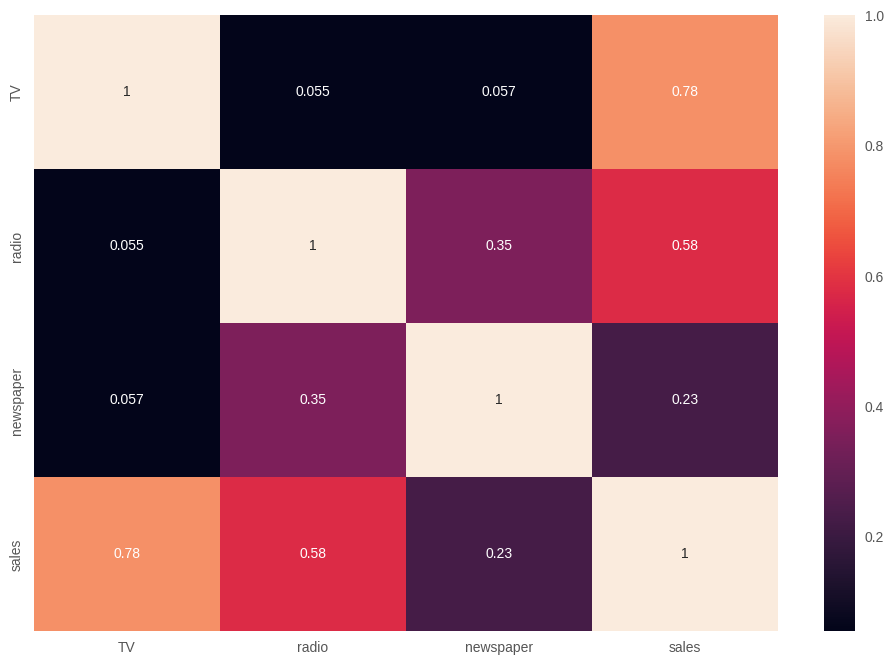

In [ ]:
sns.heatmap(df.corr(), annot=True)

Task 5 - Feature Selection

In [ ]:
from sklearn.metrics import r2_score
# Model-1 Using TV and radio

X_tv_radio = df[['TV','radio']]

# Initializing model

lm2 = LinearRegression()

# Train the model on full dataset

lm2.fit(X_tv_radio,y)

# Predict the sales using trained model

lm2_pred = lm2.predict(X_tv_radio)

# Calculate R2 score for model evaluation

R2_tv_radio = r2_score(y,lm2_pred)

print("R2 score using TV and radio : ", R2_tv_radio)

R2 score using TV and radio :  0.8971942610828957


In [ ]:
# Model-2 Using TV, Radio , newpaper

X_all_features = df[['TV','radio','newspaper']]

lm3 = LinearRegression()

lm3.fit(X_all_features,y)

lm3_pred = lm3.predict(X_all_features)

r2_all_features = r2_score(y,lm3_pred)

print("R2 score using TV and radio and newspaper : ", r2_all_features)

R2 score using TV and radio and newspaper :  0.8972106381789522


Task 6 - Model Evaluation uning Train and Test Dataset

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X = df.drop('sales', axis=1)
Y = df['sales']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)
lm4 = LinearRegression()
lm4.fit(X_train,Y_train)

lm4_pred = lm4.predict(X_test)

rmse = np.sqrt(mean_squared_error(Y_test,lm4_pred))
print(rmse)

r2_score = r2_score(Y_test,lm4_pred)
print(r2_score)

1.4113417558581587
0.8927605914615384


In [ ]:
from sklearn.metrics import r2_score
X = df.drop(['sales', 'newspaper'], axis=1)
Y = df['sales']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)
lm5 = LinearRegression()
lm5.fit(X_train,Y_train)
lm5_pred = lm5.predict(X_test)

rmse = np.sqrt(mean_squared_error(Y_test,lm5_pred))
print(rmse)

r2_score = r2_score(Y_test,lm5_pred)
print(r2_score)

1.398292489077775
0.8947344950027066


Task 7 - Model Diagnostics

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


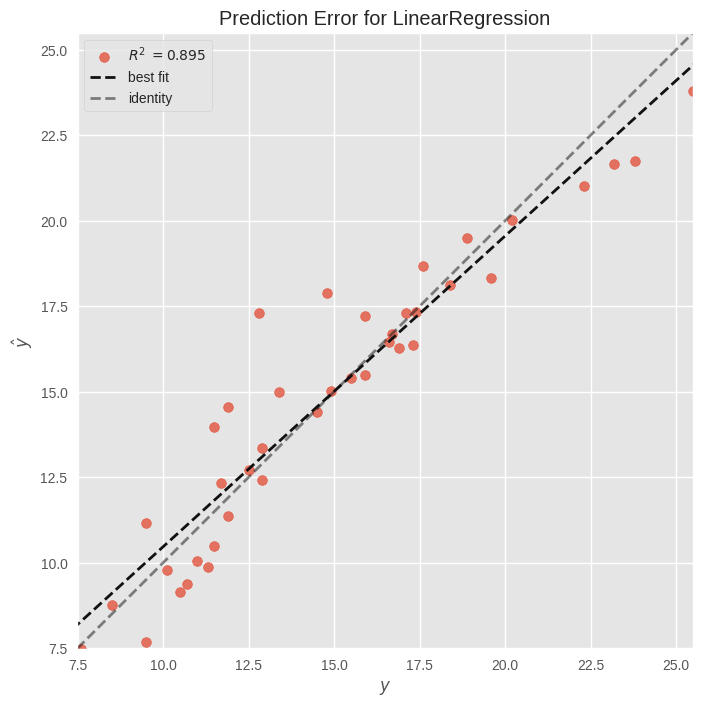

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [ ]:
from yellowbrick.regressor import ResidualsPlot, PredictionError
visualizer = PredictionError(lm5).fit(X_train, Y_train)
visualizer.score(X_test, Y_test)
visualizer.show()

Task 8 - Interaction Effects (Synergey)

In [ ]:
from sklearn.metrics import r2_score
# Creating Interaction Feature

df['TV_radio_interaction'] = df['radio']*df['TV']

# Select the feature including interaction term

X = df[['TV','radio','TV_radio_interaction']]
Y = df['sales']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=1)

#Training the Interaction Model

interaction_model = LinearRegression()

interaction_model.fit(X_train,Y_train)

Y_test_predictions = interaction_model.predict(X_test)

print("RMSE : ", np.sqrt(mean_squared_error(Y_test, Y_test_predictions)))
print("R2 Score : ", r2_score(Y_test, Y_test_predictions))

RMSE :  0.7011871137164328
R2 Score :  0.978973681468126


**Conclusion**

Task 1 – Importing Libraries

In this task, all the required Python libraries were successfully imported to support data analysis, visualization, and model building. Libraries such as Pandas and NumPy enabled data handling and numerical computation, while Seaborn and Matplotlib facilitated effective data visualization. Scikit-learn and SciPy provided the necessary tools for statistical analysis and machine learning. This step established a strong foundation for the entire project.

Task 2 – Loading the Dataset

The advertising dataset was successfully loaded using Pandas. The dataset contains information about advertising expenditure across different channels—TV, Radio, and Newspaper—and their corresponding impact on sales. Viewing the first few rows confirmed that the data was loaded correctly and was ready for exploration and analysis.

Task 3 – Relationship Between Features and Response

Using pair plots, the relationships between advertising channels and sales were visually analyzed. The plots revealed a strong positive relationship between TV and Radio advertising with sales, while Newspaper showed a weaker association. This visualization helped in understanding which features are more influential in predicting sales.

Task 4 – Multiple Linear Regression Model (Estimating Coefficients)

A multiple linear regression model was built to estimate the contribution of each advertising channel to sales. The regression coefficients indicated that TV and Radio advertising have a significant positive impact on sales, whereas Newspaper has relatively less influence. The correlation heatmap further supported these findings by showing strong correlations between sales and the TV and Radio variables.

Task 5 – Feature Selection

Feature selection was performed by comparing models using different combinations of predictors. The model using only TV and Radio achieved an R² score almost equal to the model using all three features, indicating that Newspaper does not add significant predictive power. This task demonstrated the importance of selecting relevant features to build simpler and more efficient models without sacrificing performance.

Task 6 – Model Evaluation Using Train and Test Dataset

The dataset was split into training and testing sets to evaluate model performance on unseen data. RMSE and R² scores were used as evaluation metrics. The model excluding the Newspaper feature produced better or comparable results, confirming that TV and Radio are sufficient predictors. This step ensured that the model generalizes well and is not overfitting.

Task 7 – Model Diagnostics

Model diagnostics were performed using prediction error plots. These plots helped assess how closely the predicted sales values matched the actual values. The results indicated that the model predictions were reasonably accurate and errors were evenly distributed, validating the reliability and stability of the final regression model.

Task 8 – Interaction Effects (Synergy)

An interaction term between TV and Radio advertising was introduced to capture synergy effects. The inclusion of this interaction improved model performance, as seen in better RMSE and R² values. This demonstrated that combined advertising strategies across channels can have a greater impact on sales than individual channels alone.

Overall Conclusion

This project successfully demonstrated the application of multiple linear regression to analyze the impact of advertising expenditure on sales. Through exploratory analysis, feature selection, model evaluation, diagnostics, and interaction effects, it was concluded that TV and Radio advertising are the most influential predictors of sales. The final model is accurate, interpretable, and provides valuable insights for data-driven marketing decisions